In [21]:
import config
config.configure_global_paths()
from model.ts2vec.ts2vec import TS2Vec_Learner
import numpy as np
import torch
from utils.utils import create_windows, normalise, score_windows
from model.ts2vec.utils import create_ts2vec_dataset
import matplotlib.pyplot as plt
from utils.metrics import all_metrics
from model.M_mahala.movingmahala import MovingMahalanobis
from utils.utils import flatten_data
from tqdm import tqdm

In [22]:
model = TS2Vec_Learner(
        input_dims=1,
        output_dims=12,
        train_data = np.random.randn(1,1,1),
        device="cpu",
    )
model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/model_weights.pth',
                                     map_location=torch.device('cpu')))

/tmp/ipykernel_16386/3377116783.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.net.load_state_dict(torch.load('/home/onyxia/work/moving_mahalanobis/model/ts2vec/m

<All keys matched successfully>

In [23]:
import json
with open("/home/onyxia/work/moving_mahalanobis/data/KPI_anomaly/kpi_2.json", "r") as file:
    data = json.load(file)

In [24]:
key = list(data.keys())[2]

In [25]:
import pandas as pd
seq_len = 32
X = np.array(data[key]["X"][:5000])
y = np.array(data[key]["y"][:5000])
y = create_windows(y.flatten(), seq_len=seq_len, stride=seq_len)
loader = create_ts2vec_dataset(X, model, seq_len=seq_len, stride=seq_len, device="cpu")

In [26]:
mahala = MovingMahalanobis(y, loader, model_name="TS2Vec", X=X, seq_len=32)
params = {"print_results": False, "thresh":12, "mode_auto": True,
          "windows": True, "verbose": True, "n_channels" : 12,
          "seq_len": 32, "stride":32, "model_name": "TS2Vec", "device": "cpu", "modif_score": False}
mahala.set_params(**params)
out = mahala.fit()
for key in out.keys():
    print(key, ":", out[key])

100%|██████████| 156/156 [00:05<00:00, 27.64it/s]


Accuracy : 1.0
F1 : 1.0
Precision : 1.0
Recall : 1.0
Roc_Auc : 1.0
AUPr : 1.0
FPR@95% : 0.0
n_anomaly : 2
n_data : 143
model : TS2Vec


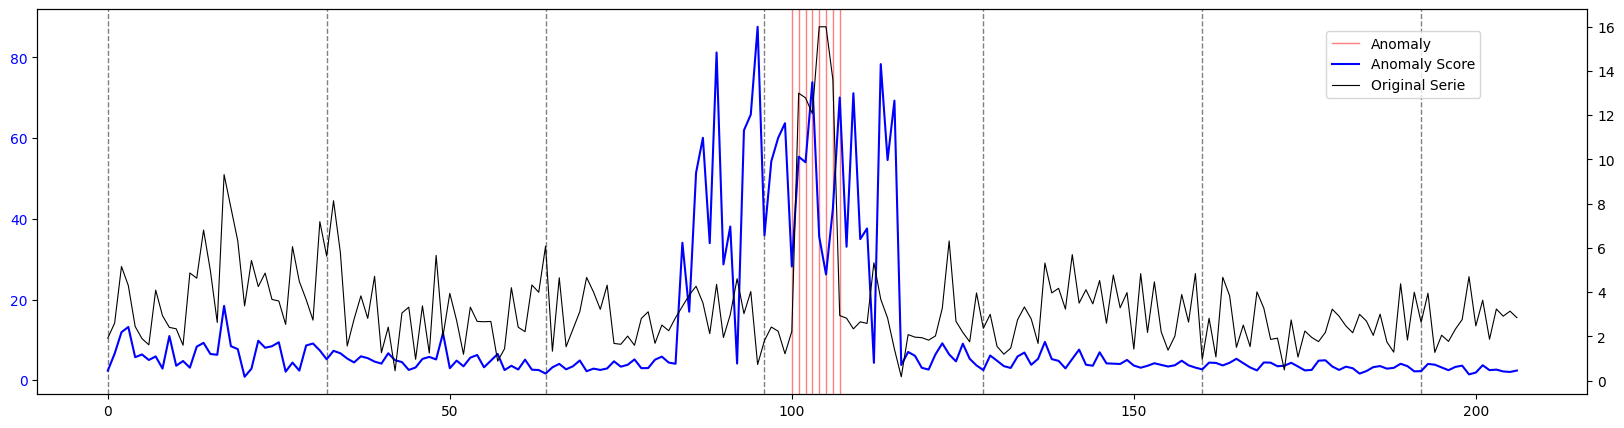

In [28]:
mahala.plot_anomalies(0)

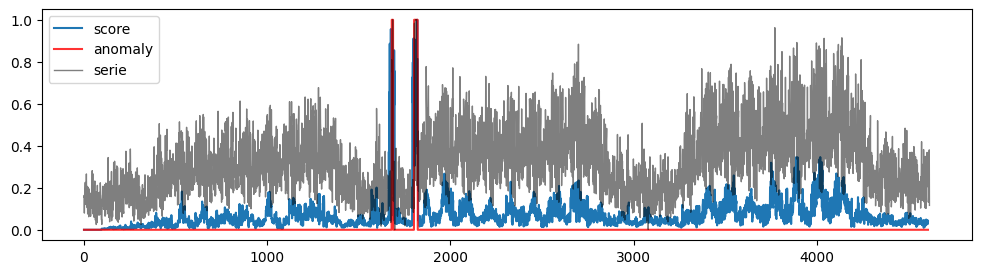

In [29]:
plt.figure(figsize=(12,3))
plt.plot(normalise(np.clip(mahala.score, None, 7000)), label="score")
plt.plot(mahala.labels, alpha=0.8, c="r", label="anomaly")
plt.plot(normalise(mahala.X.flatten()), linewidth=1, alpha=0.5, c="black", label="serie")
plt.legend()
plt.show()

Accuracy: 1.0000
F1 Score: 1.0000
Precision: 1.0000
Recall: 1.0000
AUC: 1.0000
AUPR: 1.0000
Taux de faux positifs à 95% de sensibilité : 0.0000


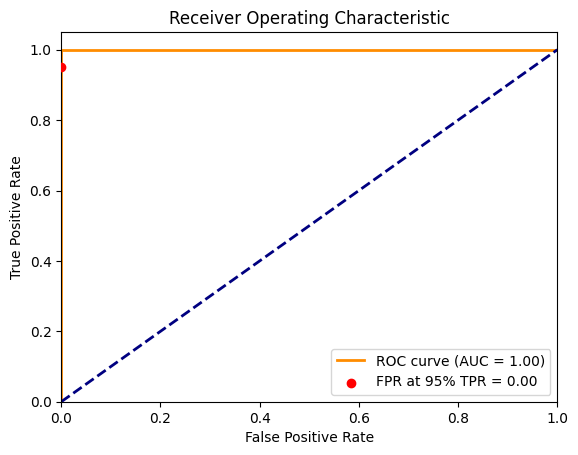

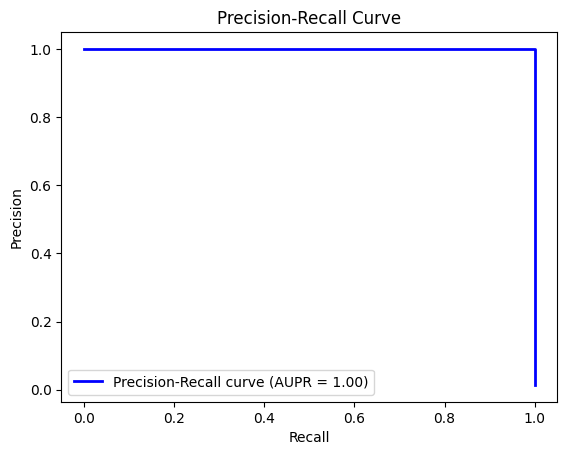

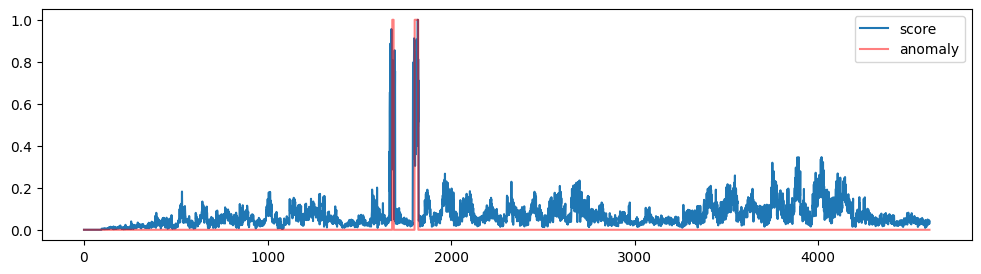

In [30]:
label_w, score_w = score_windows(mahala.labels, mahala.score, seq_len=32)
all_metrics(label_w, score_w, verbose=True)
plt.figure(figsize=(12,3))
plt.plot(normalise(np.clip(mahala.score, None, 300)), label="score")
plt.plot(mahala.labels, alpha=0.5, c="r", label="anomaly")
plt.legend()
plt.show()